In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def read_confidence_image(conf_path="./raw_data/confidence.png"):
    """
    正确读取I;16模式的16位PNG置信图，返回归一化到[0,1]的PyTorch张量
    输入: 置信图路径
    输出: conf_tensor, 形状 [1, H, W], 范围 [0.0, 1.0]
    """
    # 1. 以PIL方式打开图片，保持原始I;16模式
    img = Image.open(conf_path)
    print(f"置信图片信息: 格式={img.format}, 大小={img.size}, 模式={img.mode}")
    print(f"PIL原始像素范围: 最大值={max(img.getdata())}, 最小值={min(img.getdata())}")

    # 2. 转换为numpy数组，严格按16位无符号整数处理
    img_np = np.array(img, dtype=np.uint16)  # 形状 (H, W)

    # 3. 归一化到[0, 1]：除以16位无符号最大值65535
    img_np_normalized = img_np.astype(np.float32) / 65535.0

    conf_tensor = torch.from_numpy(img_np_normalized).unsqueeze(0)  # 形状 [1, H, W]

    # 5. 验证张量正确性
    print(f"\n置信图张量信息: 形状={conf_tensor.shape}, 最大值={conf_tensor.max().item():.4f}, 最小值={conf_tensor.min().item():.4f}")
    print(f"张量数据类型: {conf_tensor.dtype}")

    return conf_tensor

In [16]:
def read_target_image(target_path="./raw_data/target.png"):
    """
    正确读取I;16模式的16位PNG目标图，返回归一化到[0,1]的PyTorch张量
    输入: 目标图路径
    输出: target_tensor, 形状 [1, H, W], 范围 [0.0, 1.0]
    """
    # 1. 以PIL方式打开图片，保持原始I;16模式
    img = Image.open(target_path)
    print(f"原始图片信息: 格式={img.format}, 大小={img.size}, 模式={img.mode}")
    print(f"PIL原始像素范围: 最大值={max(img.getdata())}, 最小值={min(img.getdata())}")
    
    # 2. 转换为numpy数组，严格按16位无符号整数处理
    img_np = np.array(img, dtype=np.uint16)  # 形状 (H, W)
    
    # 3. 归一化到[0, 1]：除以16位无符号最大值65535
    img_np_normalized = img_np.astype(np.float32) / 65535.0
    
    # 4. 直接从numpy转PyTorch张量（高效，无冗余操作）
    target_tensor = torch.from_numpy(img_np_normalized).unsqueeze(0)  # 形状 [1, H, W]
    
    # 5. 验证张量正确性
    print(f"\n原始图张量信息: 形状={target_tensor.shape}, 最大值={target_tensor.max().item():.4f}, 最小值={target_tensor.min().item():.4f}")
    print(f"张量数据类型: {target_tensor.dtype}")
    
    return target_tensor

In [4]:
def read_reference_image(ref_path="./raw_data/reference.png"):
    img = Image.open(ref_path).convert("RGB")  
    
    # 2. 转为 PyTorch 张量 [3, H, W]，值自动归一化到 0~1
    transform = T.ToTensor()
    ref_tensor = transform(img)  
    
    print("参考图形状:", ref_tensor.shape)  # 输出 torch.Size([3, 1088, 1376])
    return ref_tensor

In [5]:
def read_ground_truth(gt_path="./raw_data/ground_truth.png"):
    # 1. 打开并强制转 8 位灰度图 L
    img = Image.open(gt_path).convert("L")  
    
    # 2. ToTensor 自动转 [0~1]，形状 [1, H, W]
    gt_tensor = T.ToTensor()(img)  
    
    return gt_tensor

In [6]:
def generate_diff_kernels(kernel_size=3):
    """
    生成任意奇数大小的差分卷积核
    每个核：中心=1，某一邻域点=-1，其余=0
    输出 shape: [out_channels, 1, kernel_size, kernel_size]
    """
    assert kernel_size % 2 == 1, "卷积核必须是奇数（3,5,7...）"
    
    center = kernel_size // 2  # 中心坐标
    kernels = []
    
    # 遍历窗口所有位置
    for i in range(kernel_size):
        for j in range(kernel_size):
            
            if i == center and j == center:
                continue  # 跳过中心点
            
            # 创建全0核
            kernel = torch.zeros(kernel_size, kernel_size)
            kernel[center, center] = 1.0  # 中心 = 1
            kernel[i, j] = -1.0           # 邻域 = -1
            kernels.append(kernel)
    
    # 堆叠成卷积需要的格式 [K**2 - 1, 1, K, K]
    kernels = torch.stack(kernels).unsqueeze(1)
    return kernels

In [7]:
def rgb_to_yuv(rgb):
    r, g, b = rgb[0:1], rgb[1:2], rgb[2:3]
    y = 0.299 * r + 0.587 * g + 0.114 * b
    u = -0.14713 * r - 0.28886 * g + 0.436 * b
    v = 0.615 * r - 0.51499 * g - 0.10001 * b
    return torch.cat([y, u, v], dim=0)

In [8]:
def compute_bilateral_weights(ref,kernel_size=5, sigma_xy=5.0, sigma_l=3.0, sigma_uv=10.0):
    _, H, W = ref.shape
    ref_yuv = rgb_to_yuv(ref)
    
    l = ref_yuv[0:1].clone()
    u = ref_yuv[1:2].clone()
    v = ref_yuv[2:3].clone()

    padding = kernel_size // 2
    kernels = generate_diff_kernels(kernel_size)

    kernels = kernels.to(ref.device)

    # ----------------------
    # 【1】亮度/色度 差值 (xi - xj)
    # ----------------------
    l_diffs = F.conv2d(l.unsqueeze(0), kernels, padding=padding)  # [1,K**2 - 1,H,W]
    u_diffs = F.conv2d(u.unsqueeze(0), kernels, padding=padding)
    v_diffs = F.conv2d(v.unsqueeze(0), kernels, padding=padding)

    # ----------------------
    # 【2】空间坐标差值 (固定位置差)
    # ----------------------
    # 生成坐标网格
    yy, xx = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
    
    yy = yy.float().unsqueeze(0).to(ref.device)
    xx = xx.float().unsqueeze(0).to(ref.device)

    # 卷积计算空间差 (yi - yj) 和 (xi - xj)
    dy = F.conv2d(yy.unsqueeze(0), kernels, padding=padding)
    dx = F.conv2d(xx.unsqueeze(0), kernels, padding=padding)
    d_pos = dy**2 + dx**2  # 空间距离平方

    print("d_pos:", d_pos.shape)

    # for i in range(kernel_size**2 - 1):
    #     print(d_pos[0][i][20][20])
    
    # 【3】权重公式
    # ----------------------
    W = torch.exp(
        - d_pos / (2 * sigma_xy**2)
        - (l_diffs **2) / (2 * sigma_l**2)
        - (u_diffs** 2 + v_diffs **2) / (2 * sigma_uv**2)
    )

    return W, kernels

In [9]:
class BilateralOptimNet(nn.Module):
    def __init__(self, init_img, ref_img, kernel_size, lambda_smooth=8.0, 
                 sigma_xy=5.0, sigma_l=3.0, sigma_uv=10.0):
        super().__init__()
        # 待优化的深度图 x
        self.x = nn.Parameter(init_img.clone())  # [1,H,W]
        
        self.lambda_smooth = lambda_smooth
        self.kernel_size = kernel_size
        self.padding = self.kernel_size // 2
        
        # 预计算双边权重 W + 差分卷积核
        self.W, self.kernels = compute_bilateral_weights(
            ref_img, kernel_size, sigma_xy, sigma_l, sigma_uv
        )

    def forward(self):
        # 加 sigmoid 强制输出 0~1
        return torch.sigmoid(self.x)

    def compute_energy_loss(self, target, conf):
        
        x_out = torch.sigmoid(self.x)
        data_loss = torch.sum(conf * (x_out - target) ** 2)

        # 用卷积计算所有邻域差值：x_i - x_j
        x_diffs = F.conv2d(
            x_out.unsqueeze(0),    # [1,1,H,W]
            self.kernels, 
            padding=self.padding
        )  # [1,K**2 - 1,H,W]

        # 加权求和：W * (x_i - x_j)^2
        smooth_term = torch.sum(self.W * (x_diffs ** 2))
        smooth_loss = 0.5 * self.lambda_smooth * smooth_term

        total_loss = data_loss + smooth_loss
        return total_loss

In [10]:
def show_gray_tensor(tensor, title_str):
    """
    输入：灰度张量
    支持：[H, W] 或 [1, H, W]
    输出：直接弹出图片窗口
    """
    # 1. 把张量从 GPU 挪到 CPU，并转成 numpy
    img_np = tensor.detach().cpu().numpy()
    
    # 2. 自动压缩多余维度 (把 [1, H, W] → [H, W])
    img_np = img_np.squeeze()
    
    # 3. 显示灰度图
    plt.figure(figsize=(10, 6))
    plt.imshow(img_np, cmap='gray')
    plt.axis('off')
    plt.title(title_str)
    plt.show()

In [11]:
def ssim(img1, img2, win_size=11, sigma=1.5, data_range=1.0):
    """
    计算 SSIM（支持单通道灰度图，如深度图）
    img1, img2: shape [1, H, W] 或 [B, 1, H, W]，值范围 0~1
    返回：标量 SSIM，越大越好（最好为1）
    """
    # 自动扩展成 [B, C, H, W] 格式
    if img1.dim() == 3:
        img1 = img1.unsqueeze(0)  # [1,1,H,W]
    if img2.dim() == 3:
        img2 = img2.unsqueeze(0)

    C1 = (0.01 * data_range) ** 2
    C2 = (0.03 * data_range) ** 2

    # 高斯窗口
    channel = img1.size(1)
    kernel = torch.ones(channel, 1, win_size, win_size, device=img1.device)
    kernel = kernel / (win_size ** 2)

    # 均值
    mu1 = F.conv2d(img1, kernel, padding=win_size//2, groups=channel)
    mu2 = F.conv2d(img2, kernel, padding=win_size//2, groups=channel)

    mu1_sq = mu1 ** 2
    mu2_sq = mu2 ** 2
    mu1_mu2 = mu1 * mu2

    # 方差 & 协方差
    sigma1_sq = F.conv2d(img1*img1, kernel, padding=win_size//2, groups=channel) - mu1_sq
    sigma2_sq = F.conv2d(img2*img2, kernel, padding=win_size//2, groups=channel) - mu2_sq
    sigma12 = F.conv2d(img1*img2, kernel, padding=win_size//2, groups=channel) - mu1_mu2

    # SSIM 公式
    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
               ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))

    return ssim_map.mean()

# 用法示例
# ssim_score = ssim(优化结果, ground_truth)
# print(f"SSIM: {ssim_score.item():.4f}")

In [12]:
def main(lr=0.1, kenerl_size=5, lambda_smooth=4.0, sigma_xy=1.0, sigma_l=1.0, sigma_uv=8.0):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    ref = read_reference_image()
    target = read_target_image()
    depth_gt = read_ground_truth()
    conf = read_confidence_image()
    
    # ref, target, depth_gt, conf = get_test_data("./data/reference.png")
    
    ref = ref.to(device)
    target = target.to(device)
    depth_gt = depth_gt.to(device)
    conf = conf.to(device)


    noise = torch.randn_like(target) * 0.1
    init_val = target + noise
    init_val = torch.clamp(init_val, 0.0, 1.0)
    
    
    model = BilateralOptimNet(
        init_img=init_val,
        ref_img=ref,
        kernel_size = kenerl_size,
        lambda_smooth=lambda_smooth,
        sigma_xy=sigma_xy,
        sigma_l=sigma_l,
        sigma_uv=sigma_uv
    ).to(device)

    optimizer = optim.SGD(model.parameters(), lr=lr)

    for it in range(1500):
        optimizer.zero_grad()
        loss = model.compute_energy_loss(target, conf)
        loss.backward()
        optimizer.step()
        if it % 100 == 0:
            print(f"Iter {it:3d} | Loss = {loss.item():.2f}")

    final_x = model().detach()
    # print(final_x)

    # show_gray_tensor(target, 'Target(Noised Depth)')
    # show_gray_tensor(final_x, 'Output')
    
    # print(F.mse_loss(target, depth_gt), F.mse_loss(final_x, depth_gt))

    print('*****************************')

    return target, final_x, depth_gt

In [17]:
# for a in [1, 2, 3, 4]:
#     for b in [1, 2, 4, 8]:
#         for c in [1, 2, 4, 8]:
#             for d in [1, 2, 4, 8]:
#                 main(a,b,c,d)

# target, final_x, depth_gt = main(0.05, 9, 0.1, 4, 2, 6)
target, final_x, depth_gt = main(lr=0.05, kenerl_size=9, lambda_smooth=0.1, sigma_xy=4, sigma_l=2, sigma_uv=6)


Using device: cuda
参考图形状: torch.Size([3, 1088, 1376])
原始图片信息: 格式=PNG, 大小=(1376, 1088), 模式=I;16
PIL原始像素范围: 最大值=58256, 最小值=13499

原始图张量信息: 形状=torch.Size([1, 1088, 1376]), 最大值=0.8889, 最小值=0.2060
张量数据类型: torch.float32
置信图片信息: 格式=PNG, 大小=(1376, 1088), 模式=I;16
PIL原始像素范围: 最大值=65535, 最小值=1976

置信图张量信息: 形状=torch.Size([1, 1088, 1376]), 最大值=1.0000, 最小值=0.0302
张量数据类型: torch.float32
d_pos: torch.Size([1, 80, 1088, 1376])
Iter   0 | Loss = 20752.24
Iter 100 | Loss = 9755.95
Iter 200 | Loss = 6309.65
Iter 300 | Loss = 4170.54
Iter 400 | Loss = 2832.47
Iter 500 | Loss = 1991.85
Iter 600 | Loss = 1459.21
Iter 700 | Loss = 1118.22
Iter 800 | Loss = 897.55
Iter 900 | Loss = 753.26
Iter 1000 | Loss = 657.98
Iter 1100 | Loss = 594.47
Iter 1200 | Loss = 551.78
Iter 1300 | Loss = 522.82
Iter 1400 | Loss = 503.04
*****************************


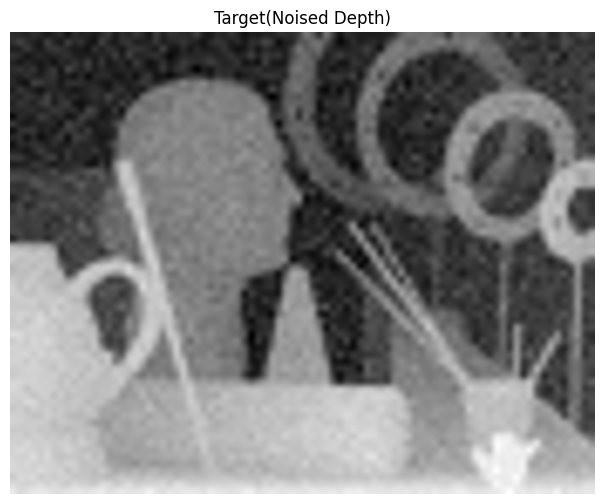

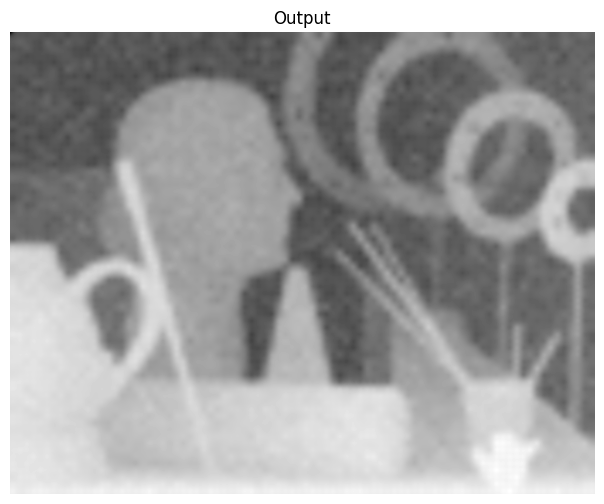

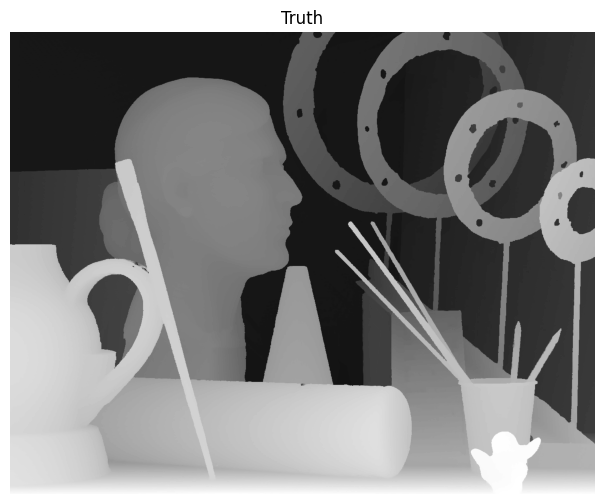

In [18]:
show_gray_tensor(target, 'Target(Noised Depth)')
show_gray_tensor(final_x, 'Output')
show_gray_tensor(depth_gt, 'Truth')

In [19]:
ssim_before = ssim(target, depth_gt)    # 加噪初始图 vs 真值
ssim_after = ssim(final_x, depth_gt)      # 优化后 vs 真值

print(f"SSIM 优化前: {ssim_before.item():.4f}")
print(f"SSIM 优化后: {ssim_after.item():.4f}")

SSIM 优化前: 0.8426
SSIM 优化后: 0.8721
